In [1]:
import io
import os
import re
import csv
import duckdb
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from huggingface_hub import hf_hub_download
from datasets import DatasetDict, Image, load_dataset

/Users/ashapatel/Documents/projects/fake-image-detection/vit_pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# this is a list of detectors with an LLM component

mllm_generators = {
    "gpt-image-1",
    "gpt-image-1.5",
    "gpt-image-2.0",
    "nano-banana",
    "nano-banana-pro",
    "imagen-3",
    "imagen-4",
    "ideogram-2.0",
    "ideogram-3.0",
    "grok-2-image-1212",
    "DALL·E 3",
    "qwen-image",
    "z-image-turbo",
    "mystic",
    "aurora",
    "lumina",
    "kolors",
    "hidream-i1-full",
}

# OpenFake dataset

## Downloading a shard of the dataset

I downloaded a single shard of the training data to open and inspect.

See https://huggingface.co/datasets/ComplexDataLab/OpenFake

In [ ]:
train_shard0 = pd.read_parquet("../data/train-00016-of-00032-00016.parquet", engine="pyarrow")

In [ ]:
train_shard0

Loading the parquet file into a dataframe, we can see there are 6 columns and 4000 rows, with each row corresponding to an image.

The columns are:
- image (bytes)

- prompt: the prompt used to generate the image, or for real images this is just a caption
- label: 'real' or 'fake'
- model: for fake images this is the generator name e.g 'flux.2-dev', and for real images this is the name of the dataset the image comes from e.g 'laion'
- type: generator class: base, finetune, lora, image (for non-generator real photos), video (for frames extracted from text-to-video / image-to-video models).
- release_date: first release date of the generator, or collection date for real images. Format varies (YYYY-MM or YYYY-MM-DD).

In [ ]:
# Data correction: all 227 'sd-2.1' rows are tagged release_date "2024-01", but
# Stable Diffusion 2.1 was actually released in December 2022.
train_shard0.loc[train_shard0["model"] == "sd-2.1", "release_date"] = "2022-12"

### Feature distributions

In [ ]:
train_shard0["label"].value_counts()

In [ ]:
import matplotlib.pyplot as plt

# Fixed, colorblind-safe categorical order (never cycled/rainbow).
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
OTHER_COLOR = "#9c9c9c"


def plot_pie(counts: pd.Series, title: str, top_n: int = 7) -> None:
    """Pie chart from a value_counts series, folding anything past top_n into 'Other'.

    Category names go in a legend rather than on the wedges, so labels for
    similarly-sized slices don't overlap; only the percentage stays on the wedge.
    """
    if len(counts) > top_n:
        counts = pd.concat([counts.iloc[:top_n], pd.Series({"Other": counts.iloc[top_n:].sum()})])
    colors = CATEGORICAL[: len(counts)]
    if "Other" in counts.index:
        colors[-1] = OTHER_COLOR
    plt.figure(figsize=(6, 5))
    wedges, _, _ = plt.pie(counts, autopct="%1.0f%%", colors=colors, startangle=90, pctdistance=0.8)
    plt.legend(wedges, counts.index, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
train_shard0["label"].value_counts()

In [ ]:
train_shard0[train_shard0["label"] == "fake"]["model"].value_counts()

In [ ]:
plot_pie(train_shard0["label"].value_counts(), "Label distribution")

We have roughly 2000 images in each of the 'fake' and 'real' subsets.

In [ ]:
counts = train_shard0.loc[train_shard0["label"] == 'real', "model"].value_counts()
plot_pie(counts[counts > 1], f"Model distribution (real)", top_n = 20)

The real images come from the 'laion' and 'pexels' dataset, nearly 50/50.

The huggingface dataset source states that 'laion' contains 'politically salient or newsworthy images' and 'carries authentic web compression artifacts'.

The 'pexels' dataset is described as 'high-quality stock photographs'.

In [ ]:
fake = train_shard0[train_shard0["label"] == "fake"]
fake_counts = fake["model"].value_counts()
fake_counts = fake_counts[fake_counts > 10].sort_values()

# A few models have a handful of rows tagged with a stray off-year; take the mode
# so each model gets a single representative release year.
model_year = fake.groupby("model")["release_date"].agg(lambda s: s.str[:4].mode()[0])
labels = [f"{model} ({model_year[model]})" for model in fake_counts.index]

In [ ]:
fake_type = train_shard0.loc[train_shard0["label"] == "fake", "type"].replace(
    {"Base": "base"}
)
plot_pie(fake_type.value_counts(), "Type distribution (fake)")

68% of the fake images come from base models, which presumably overlaps with the 'frontier proprietary models' and 'open source flagships' categories listed on the huggingface dataset website. The other 32%, which include 'finetune' and 'lora', presumably overlap with the 'community fine-tunes and LoRAs (sampled from Civitai)' category.

In [ ]:
# Same models/counts as the bar chart above, but year is a real axis instead of label text.
from adjustText import adjust_text

plt.figure(figsize=(9, 7))
years = model_year.loc[fake_counts.index].astype(int)
plt.scatter(years, fake_counts.values, color=CATEGORICAL[0])
texts = [
    plt.annotate(model, (year, count), fontsize=8)
    for model, year, count in zip(fake_counts.index, years, fake_counts.values)
]
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
plt.xlabel("Release year")
plt.ylabel("Count")
plt.title("Model usage vs. release year (fake, count > 20)")
plt.tight_layout()
plt.show()

This scatter plot shows that the majority of the fake images were generated by models released in 2024, e.g stable diffusion 3.5 and flux.1-dev. The former is the most significant contributor, with ~250 images, followed by stable diffusion 2.1, with ~225, which was released in 2022. The majority of models contribute between 20 and 70 fake images to the dataset.

For the 12 generators contributing at least 50 images to the dataset, I asked Claude to look up their architecture, e.g GAN, diffusion or LLM-based. 11 of the models cam back as diffusion-based, and only one as LLM-based (GPT image-1, contributing only 60 images).

To get more LLM-generated images I'd need to download more shards of the dataset, but there's a risk that the distribution of generator types in each shard will be similar. 

A solution to this could be streaming; see a later section! Before that, let's take a closer look at the diffusion-generated images downloaded in this shard.

### Diffusion-generated images

## Streaming the whole dataset

Instead of downloading shards of the dataset only to find that they contain very few non-diffusion-generated images, by streaming the huggingface dataset I should be able to filter on the model names that I'm interested and download images from only those models.

In [ ]:
dataset = load_dataset("ComplexDataLab/OpenFake", "core", split="train", streaming=True)

In [ ]:
print(next(iter(dataset)))

In [ ]:
# streams the huggingface dataset and iterates through each row
# if the model is in the mllm_generators list, then the image gets saved locally
# the metadata for each saved image, e.g. filename, model, label, release_date, is written to a manifest.csv file

MAX_IMAGES_PER_GENERATOR = 50

OUTPUT_FOLDER = "../data/mllm_fakes"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

ds = load_dataset("ComplexDataLab/OpenFake", "core", split="train", streaming=True)
ds = ds.cast_column(
    "image", Image(decode=False)
)  # now row["image"] is {"bytes":..., "path":...}, otherwise when I load a row I get an error when the image is not a valid image file

kept = Counter()

with open(f"{OUTPUT_FOLDER}/manifest.csv", "w", newline="") as manifest:
    w = csv.writer(manifest)
    w.writerow(["filename", "model", "label", "release_date"])

    for row_num, row in tqdm(enumerate(ds)):
        if row["label"] != "fake":
            continue
        model = row["model"]
        if model not in mllm_generators or kept[model] >= MAX_IMAGES_PER_GENERATOR:
            continue
        filename = f"{model}_{kept[model]:04d}.png"  # PNG, not JPG — see below
        try:
            img = PILImage.open(io.BytesIO(row["image"]["bytes"]))
            img.save(f"{OUTPUT_FOLDER}/{filename}")
        except Exception as e:
            print(f"  skipped bad image ({model}): {e!r}")
            continue  # don't count it, don't write manifest row, move on

        w.writerow([filename, model, row["label"], row["release_date"]])
        kept[model] += 1

        if all(kept[m] >= MAX_IMAGES_PER_GENERATOR for m in mllm_generators):
            break

print(kept)

In [ ]:
folder_path = Path(OUTPUT_FOLDER)
len(os.listdir(folder_path))

After streaming for ~90 minutes, we only have 280 images generated by MLLMs.

Before we decide what to do next, let's look at how many images come from each model.

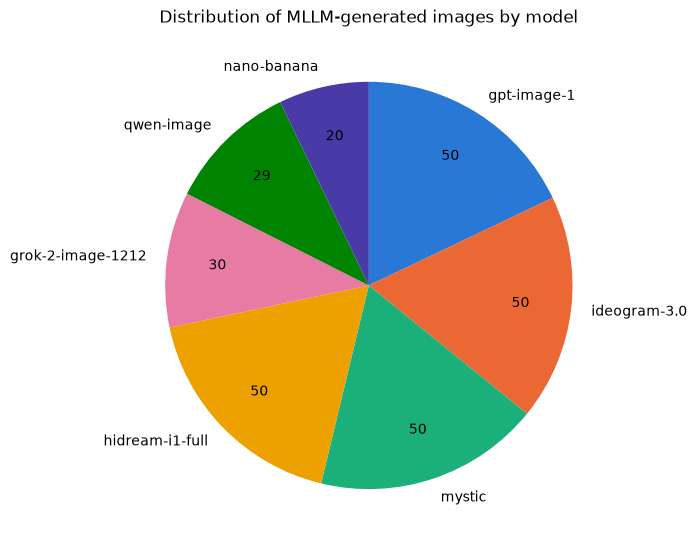

In [13]:
pattern = re.compile(r"^(.+)_\d{4}\.\w+$")
counts = Counter(
    m.group(1)
    for p in Path("../data/mllm_fakes").iterdir()
    if (m := pattern.match(p.name))
)
labels, values = zip(*counts.most_common())

colors = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
    "#e34948",
][: len(labels)]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    values,
    labels=labels,
    colors=colors,
    autopct=lambda p: f"{round(p / 100 * sum(values))}",
    pctdistance=0.75,
    startangle=90,
    counterclock=False,
)
ax.set_title("Distribution of MLLM-generated images by model")
plt.tight_layout()
plt.show()

We have the following number of images per model:

- qwen-image: 29
- nano-banana: 20
- mystic: 50
- ideogram-3.0: 50
- hidream-i1-full: 50
- grok-2-image-1212: 30
- gpt-image-1: 50

Note that I capped the maximum number of images per model at 50, so there are likely more in the dataset. However, given how long it took to stream just 280 images, it's worth considering whether there's a better approach.

For fine-tuning, we are aiming for 1000 MLLM-generated images, alongside 1000 from GANs and another 1000 from diffusion models. For testing we want 1000 MLLM-generated images from the most modern MLLM that we can find.



Here are the release dates of the MLLMs in the OpenFake dataset:

- qwen-image: 2025-08-02
- nano-banana: 2025-08
- mystic: 2024-01
- ideogram-3.0: 2025-03
- hidream-i1-full: 2024-01
- grok-2-image-1212: 2024-12
- gpt-image-1: 2025-04

## Querying the dataset

In [7]:
def query_dataset_shard(shard_name: str) -> pd.DataFrame:
    con = duckdb.connect()
    con.execute("INSTALL httpfs; LOAD httpfs;")

    # point at the auto-converted parquet for the split
    url = f"hf://datasets/ComplexDataLab/OpenFake/core/{shard_name}.parquet"

    # count per generator WITHOUT downloading images — reads only the 'model' column
    df = con.execute(f"""
        SELECT model, count(*) AS n
        FROM '{url}'
        WHERE label = 'fake'
            AND model IN ({','.join(f"'{m}'" for m in mllm_generators)})
        GROUP BY model
        ORDER BY n DESC
    """).df()
    return(df)

First I tried specifying the url with "train-*.parquet" to loop through all shards, but this failed with a 'too many requests' error.

The structure of the dataset is: 32 groups, 18 parquet files per group, i.e the 'train-00000' goes up to 'train-00032' and the suffixes range from 00000 to 00018 for each group.

I tried specifying a single shard per query then looping through the 18 shards in the first group, and this worked.

In [8]:
def get_model_counts_per_shard_group(shard_group: str) -> pd.DataFrame:

    shard_names = [f"{shard_group}-of-00032-{i:05d}" for i in range(18)]

    records = []
    for shard_name in tqdm(shard_names):
        df = query_dataset_shard(shard_name)
        df = df[df["n"] > 50]
        df["shard"] = shard_name
        records.append(df)

    combined = pd.concat(records, ignore_index=True)
    
    return combined

In [ ]:
shard_groups = [f"train-{i:05d}" for i in range(32)]

all_shard_group_results = []    
for shard_group in shard_groups[28:32]:
    totals = get_model_counts_per_shard_group(shard_group)
    print(f"Shard group {shard_group}:")
    print(totals)
    all_shard_group_results.append(totals)

100%|██████████| 18/18 [02:45<00:00,  9.22s/it]


Shard group train-00002:
              model   n                       shard
0       gpt-image-1  77  train-00002-of-00032-00000
1       gpt-image-1  66  train-00002-of-00032-00001
2       gpt-image-1  73  train-00002-of-00032-00002
3   hidream-i1-full  57  train-00002-of-00032-00002
4      ideogram-3.0  55  train-00002-of-00032-00002
5       gpt-image-1  71  train-00002-of-00032-00003
6       gpt-image-1  57  train-00002-of-00032-00004
7   hidream-i1-full  54  train-00002-of-00032-00004
8       gpt-image-1  74  train-00002-of-00032-00005
9       gpt-image-1  70  train-00002-of-00032-00006
10      gpt-image-1  73  train-00002-of-00032-00007
11  hidream-i1-full  57  train-00002-of-00032-00007
12      gpt-image-1  87  train-00002-of-00032-00008
13      gpt-image-1  83  train-00002-of-00032-00009
14      gpt-image-1  67  train-00002-of-00032-00010
15     ideogram-3.0  58  train-00002-of-00032-00010
16      gpt-image-1  68  train-00002-of-00032-00011
17  hidream-i1-full  52  train-00002-of

100%|██████████| 18/18 [03:22<00:00, 11.24s/it]

Shard group train-00003:
              model   n                       shard
0       gpt-image-1  72  train-00003-of-00032-00000
1       gpt-image-1  74  train-00003-of-00032-00001
2   hidream-i1-full  51  train-00003-of-00032-00001
3       gpt-image-1  79  train-00003-of-00032-00002
4   hidream-i1-full  61  train-00003-of-00032-00002
5      ideogram-3.0  61  train-00003-of-00032-00002
6       gpt-image-1  80  train-00003-of-00032-00003
7       gpt-image-1  75  train-00003-of-00032-00004
8      ideogram-3.0  54  train-00003-of-00032-00004
9       gpt-image-1  85  train-00003-of-00032-00005
10     ideogram-3.0  52  train-00003-of-00032-00005
11      gpt-image-1  81  train-00003-of-00032-00006
12      gpt-image-1  65  train-00003-of-00032-00007
13     ideogram-3.0  57  train-00003-of-00032-00007
14  hidream-i1-full  51  train-00003-of-00032-00007
15      gpt-image-1  70  train-00003-of-00032-00008
16     ideogram-3.0  53  train-00003-of-00032-00008
17      gpt-image-1  67  train-00003-of

In [ ]:
all_shard_group_results_df = pd.concat(all_shard_group_results, ignore_index=True)

totals = (
    all_shard_group_results_df.groupby("model")["n"].sum().sort_values(ascending=False)
)
totals

model
gpt-image-1        2705
ideogram-3.0        836
hidream-i1-full     503
Name: n, dtype: int64

Results from shard groups 0 & 1:

- gpt-image-1: 2573
- hidream-i1-full: 718
- ideogram-3.0: 660

Results from shard groups 2 & 3:

- gpt-image-1: 2705
- ideogram-3.0: 836
- hidream-i1-full: 503

The fact that the first 4 shards contain fake images from the same 3 generators suggests that the data is grouped by generator. Next I'll try sampling from a later shard to see if this yields fake images from a different set of generators.

## Streaming a single shard

Now, for each shard, I know how many fake images it contains and which models generated them.

Therefore I know which shards I want to download images from.

I will download real images from the same shards. Since I'm downloading from the training split of shards, the real images should all come from LAION, but I'll filter by `model="LAION"` to be sure.

In [3]:
# stream from ONE shard, not the whole config
ds = load_dataset(
    "parquet",
    data_files="hf://datasets/ComplexDataLab/OpenFake/core/train-00016-of-00032-00016.parquet",
    split="train",
    streaming=True,
)



In [ ]:
MAX_IMAGES_PER_GENERATOR = 1000
MAX_REAL_IMAGES = 1000
MAX_IMAGES_PER_DIFFUSION_GENERATOR = 500

FAKE_MLLMs_FOLDER = "../data/shard16_fakes_MLLMs"
FAKE_DIFFUSION_FOLDER = "../data/shard16_fakes_diffusion"
REAL_FOLDER = "../data/shard16_reals"

os.makedirs(FAKE_MLLMs_FOLDER, exist_ok=True)
# os.makedirs(FAKE_DIFFUSION_FOLDER, exist_ok=True)
os.makedirs(REAL_FOLDER, exist_ok=True)

ds = ds.cast_column(
    "image", Image(decode=False)
)  # now row["image"] is {"bytes":..., "path":...}, otherwise when I load a row I get an error when the image is not a valid image file

real = Counter()
fake_mllm = Counter()
# fake_diffusion = Counter()

for row_num, row in tqdm(enumerate(ds)):

    model = row["model"]

    try:
        img = PILImage.open(io.BytesIO(row["image"]["bytes"]))

        if row["label"] == "real":
            if model == "laion" and real[model] < MAX_REAL_IMAGES:
                filename = f"{model}_{real[model]:04d}.png"
                img.save(f"{REAL_FOLDER}/{filename}")
                real[model] += 1
        else:
            if model in mllm_generators and model != "laion":
                if fake_mllm[model] >= MAX_IMAGES_PER_GENERATOR:
                    continue
                filename = f"{model}_{fake_mllm[model]:04d}.png"
                img.save(f"{FAKE_MLLMs_FOLDER}/{filename}")
                fake_mllm[model] += 1
            # else:
            #     if (
            #         model != "laion"
            #         and fake_diffusion[model] >= MAX_IMAGES_PER_DIFFUSION_GENERATOR
            #     ):
            #         continue
            #     filename = f"{model}_{fake_diffusion[model]:04d}.png"
            #     img.save(f"{FAKE_DIFFUSION_FOLDER}/{filename}")
            #     fake_diffusion[model] += 1

    except Exception as e:
        print(f"  skipped bad image ({model}): {e!r}")
        continue

1612it [03:21,  1.99it/s]

  skipped bad image (laion): OSError('cannot write mode CMYK as PNG')


4000it [07:59,  8.34it/s]


In [5]:
fake_mllm

Counter({'gpt-image-1': 66,
         'ideogram-3.0': 51,
         'hidream-i1-full': 45,
         'mystic': 23,
         'qwen-image': 21,
         'grok-2-image-1212': 13,
         'nano-banana': 8})

In [ ]:

fake_diffusion

Counter({'sd-3.5': 257,
         'sd-2.1': 236,
         'flux.1-dev': 177,
         'sdxl-epic-realism': 108,
         'midjourney-6': 95,
         'flux.1-schnell': 75,
         'sdxl': 74,
         'sd-1.5-dreamshaper': 71,
         'sdxl-touchofrealism': 54,
         'flux-1.1-pro': 52,
         'dalle-3': 50,
         'sdxl-realvis-v5': 46,
         'sdxl-juggernaut': 39,
         'sd-1.5': 36,
         'sd-1.5-epicdream': 35,
         'flux-mvc5000': 28,
         'stable-diffusion-v1-5': 22,
         'flux.2-dev': 22,
         'imagen-4.0': 19,
         'flux.2-klein-4b': 15,
         'sd-xl-v1.0-vae-fix': 14,
         'realistic_vision_v5.1_novae': 14,
         'novaanimexl_ilv140': 11,
         'tiny-random-sana': 11,
         'flux.2-klein-base-4b': 11,
         'playground-v2.5-1024px-aesthetic': 11,
         'chroma': 11,
         'animagine-xl-3.0': 10,
         'sdxl-turbo': 10,
         'stable-diffusion-v1-4': 10,
         'anima-preview': 9,
         'imagen-3.0-002': 9

In [18]:
60+44+42+22+12+10+10+66+51+45+23+21+13+8

427

First I downloaded shard `train-00000-of-00032-00000.parquet` and ran the above code. I saved them in folder prefixed `shard0`.

From this shard I got 1069 real images, and the following distribution of fakes:

- gpt-image-1: 60
- hidream-i1-full: 44
- ideogram-3.0: 42
- mystic: 22
- qwen-image: 12 (consider using for testing)
- nano-banana: 10 (consider using for testing)
- grok-2-image-1212: 10

Next I downloaded `train-00016-of-00032-00016.parquet`, which contained 1000 real images and the following distribution of MLLM-generated fakes:

- gpt-image-1: 66
- ideogram-3.0: 51
- hidream-i1-full: 45
- mystic: 23
- qwen-image: 21 (consider using for testing)
- grok-2-image-1212: 13 (consider using for testing)
- nano-banana: 8


Additionally I saved the diffusion-generated images from this shard (1746 in total):

- sd-3.5: 257
- sd-2.1: 236
- flux.1-dev: 177
- sdxl-epic-realism: 108
- midjourney-6: 95
- flux.1-schnell: 75
- sdxl: 74
- sd-1.5-dreamshaper: 71
- sdxl-touchofrealism: 54
- flux-1.1-pro: 52
- dalle-3: 50

The current totals are:
- 2069 real images
- 371 MLLM-generated images for fine-tuning
- 56 MLLM-generated images for testing (from nano banana & qwen image)
- 1746 diffusion-generated images

I still need

- ~1000 real images
- ~600 MLLM-generated images for fine-tuning
- 500-1000 MLLM-generated images for testing (ideally from nano banana & qwen-image)

I was planning to fine-tune on 1000 GAN-generated images too, but I might leave this out since it'll be difficult to find a separate GAN-generated set with similar content to the OpenFake dataset.
